# Importing cadastral data

Brendan Harmon  
2026-08-30

<figure>
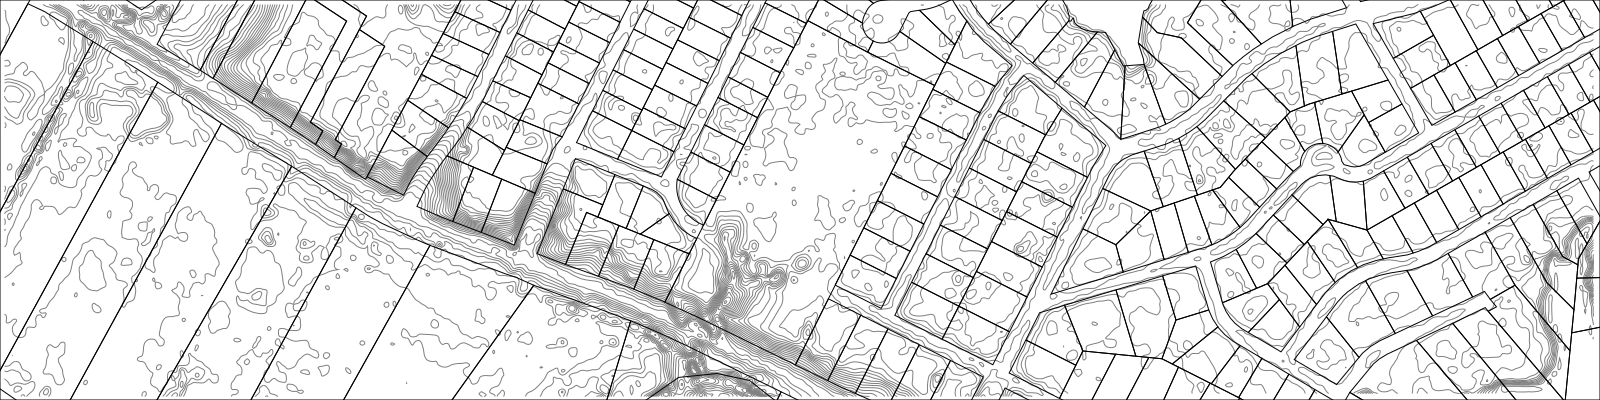
<figcaption aria-hidden="true">Importing cadastral data</figcaption>
</figure>

Learn how to import cadastral data, extract a parcel, and set your
computational region.

> **Data**
>
> Download
> [parcels](https://data-ebrgis.opendata.arcgis.com/datasets/0f69c6a9d0e944178799ccd834f4aec5_0/)
> in geojson format from East Baton Rouge Parish’s Open Data Portal.

## Setup

Start a GRASS session in a new project. Set the coordinate reference
system for the project to Louisiana State Plane South using EPSG code
2801.

In [1]:
# Import modules
import sys
import subprocess
import numpy as np

# Find GRASS Python packages
sys.path.append(
  subprocess.check_output(
    ["grass", "--config", "python_path"],
    text=True
    ).strip()
  )

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj
from grass.tools import Tools

# Create GRASS project
gs.create_project("hilltop", epsg="2801", overwrite=True)

# Initialize GRASS session
gj.init("hilltop")
tools = Tools(overwrite=True)

# Print projection
projection = tools.g_proj(format="shell", flags="p").keyval
print(projection.get("name"))

## Set computational region

In [2]:
# Set region
tools.g_region(n=206040, s=205640, e=1023700, w=1022100, res=1)

## Import parcels

In [3]:
# Import parcels
tools.v_import(input="Tax_Parcel.geojson", output="parcels", extent="region")

## Visualize parcels

In [4]:
# Visualize
m = gj.Map(width=1600)
m.d_vect(map="region", color="white", fill="black")
m.d_vect(map="contours", color="grey", size=0.5)
m.d_vect(map="parcels", color="white", fill="none", size=10)
m.show()

<figure>
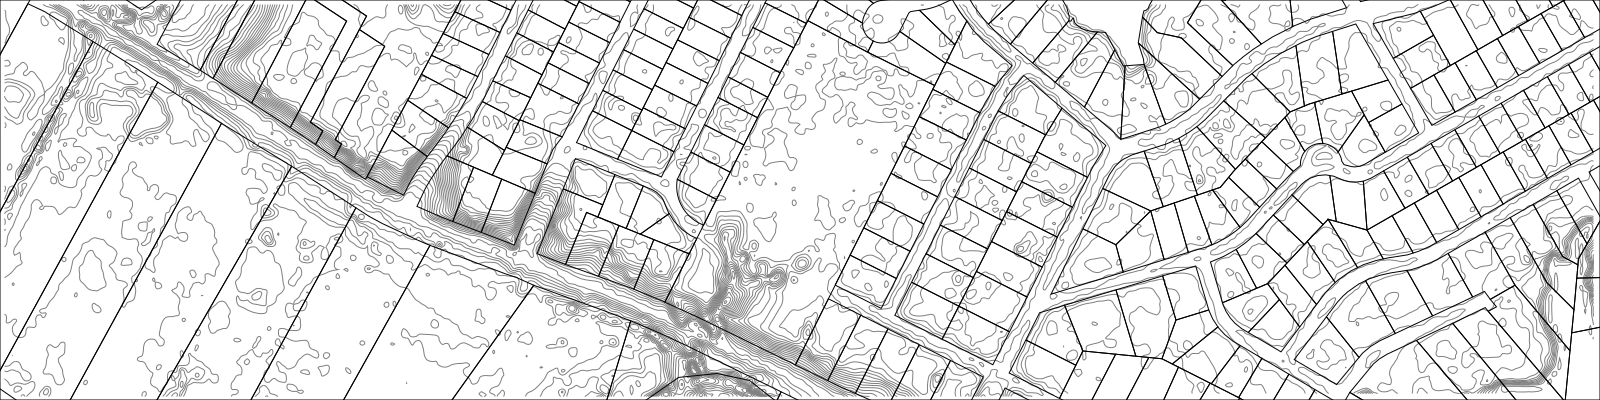
<figcaption aria-hidden="true">Parcels</figcaption>
</figure>

<!-- v.in.region -->

## Extract parcel

In [5]:
# Extract parcel by ID
tools.v_extract(input="parcels", output="parcel", where="ID=26020")

In [6]:
# Extract parcel by address
tools.v_extract(input="parcels", output="parcel", where="PHYSICAL_ADDRESS='11855 HIGHLAND RD'")

## Visualize parcel

In [7]:
# Visualize
m = gj.Map(width=1600)
m.d_vect(map="region", color="white", fill="black")
m.d_vect(map="parcels", color="grey", fill="none", size=1)
m.d_vect(map="parcel", color="white", fill="none", size=10)
m.show()

<figure>
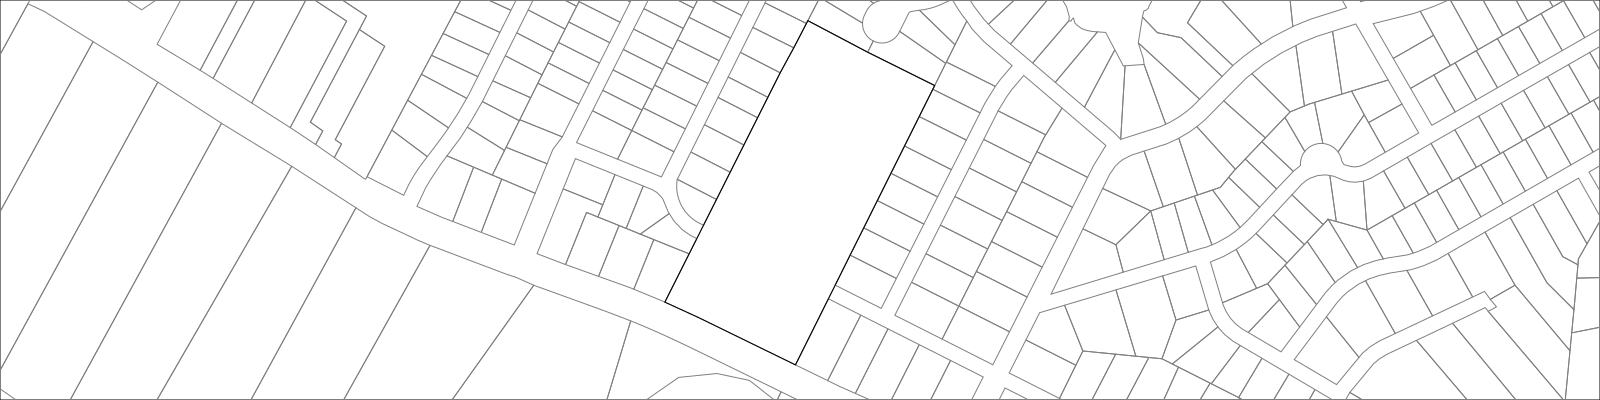
<figcaption aria-hidden="true">…</figcaption>
</figure>

## Set computational region

Set your computational region to the vector map with your parcel.

In [8]:
tools.g_region(vector="parcel")